In [14]:

# ── CELL 1: Mount Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/article_data")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family":       "Liberation Sans",
    "font.size":         9,
    "font.weight":       "normal",
    "axes.titleweight":  "normal",
    "axes.labelweight":  "normal",
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.0,
    "legend.frameon":    False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
})

C_BLUE = "#4472C4"; C_RED = "#C00000"; C_ORANGE = "#ED7D31"; C_GREY = "#888888"

print("Drive mounted OK")
print(f"Files in DATA_DIR: {len(list(DATA_DIR.iterdir()))}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted OK
Files in DATA_DIR: 41


In [15]:

# ── CELL 2: Load data and rebuild TF-IDF + SHAP ──────────────
# !pip install scikit-learn shap pandas pyarrow

import shap
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load splits
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df  = pd.read_parquet(DATA_DIR / "test.parquet")

X_train_full = train_df["text_full"].fillna("").values
X_test_full  = test_df["text_full"].fillna("").values
y_train_clf  = train_df["high_risk"].values
y_test_clf   = test_df["high_risk"].values

print(f"Train: {len(train_df):,}  Test: {len(test_df):,}")



Train: 129,509  Test: 41,413


In [16]:
# ── CELL 3 (FIXED): Expanded CVE stoplist ────────────────────

# Unigram stopwords — загальні + CVE-специфічні
CVE_UNIGRAM_STOP = {
    # Articles, prepositions, conjunctions
    "and", "or", "the", "a", "an", "in", "of", "to", "for",
    "is", "are", "was", "were", "be", "been", "being",
    "it", "its", "this", "that", "these", "those",
    "with", "by", "from", "on", "at", "as", "via",
    "not", "no", "has", "have", "had", "can", "could",
    "may", "might", "will", "would", "do", "does", "did",
    "when", "where", "which", "who", "what", "how",
    "through", "before", "after", "into", "upon",
    "also", "then", "than", "there", "their",
    "if", "but", "so", "because", "due",
    # Single letters and digits
    "n", "s", "x", "v", "e", "c", "r",
    "0","1","2","3","4","5","6","7","8","9",
    # NVD boilerplate unigrams
    "vulnerability", "issue", "allows", "affects",
    "versions", "version", "product", "software",
    "users", "user", "attacker", "attackers",
    "affect", "affected", "could", "attack",
}

# Bigram stoplist — function word bigrams
CVE_BIGRAM_STOP = {
    "from through", "a through", "and the", "and a",
    "vulnerability in", "vulnerability that",
    "the vulnerability", "a vulnerability",
    "this vulnerability", "the issue", "an issue",
    "issue in", "issue that", "issue with",
    "through the", "through a",
    "allows to", "allows a", "allows the",
    "it to", "it is", "it was",
    "to the", "to a", "to be",
    "of the", "of a", "of this",
    "in the", "in a", "in this",
    "for the", "for a",
    "via the", "via a",
    "that is", "that are", "which is",
    "can be", "could be", "may be",
    "has been", "have been",
    "due to", "due the",
    "before the", "before a",
    "with the", "with a",
    "by the", "by a",
    "when the", "when a",
    "if the", "if a",
    "issue affects", "issue was",
    "are affected", "is affected",
    "not properly", "does not",
    "users to", "user to",
    "attacker to", "attacker can",
}

print(f"Unigram stoplist: {len(CVE_UNIGRAM_STOP)} entries")
print(f"Bigram stoplist:  {len(CVE_BIGRAM_STOP)} entries")

Unigram stoplist: 96 entries
Bigram stoplist:  65 entries


In [17]:
# ── CELL 4 (FIXED): Custom analyzer with both filters ─────────
def custom_analyzer(text):
    tokens = text.lower().split()

    # Filter: remove pure digits and single chars
    tokens = [t for t in tokens
              if not t.isdigit() and len(t) > 1]

    features = []

    # Unigrams — filter stopwords
    for t in tokens:
        if t not in CVE_UNIGRAM_STOP:
            features.append(t)

    # Bigrams — filter bigram stoplist
    for i in range(len(tokens) - 1):
        bigram = f"{tokens[i]} {tokens[i+1]}"
        if bigram not in CVE_BIGRAM_STOP:
            # Also skip bigrams where both words are stopwords
            if not (tokens[i] in CVE_UNIGRAM_STOP and
                    tokens[i+1] in CVE_UNIGRAM_STOP):
                features.append(bigram)

    return features

tfidf_clean = TfidfVectorizer(
    analyzer=custom_analyzer,
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
)

print("Fitting TF-IDF with expanded stoplist...")
X_train_clean = tfidf_clean.fit_transform(X_train_full)
X_test_clean  = tfidf_clean.transform(X_test_full)
print(f"Vocabulary: {len(tfidf_clean.vocabulary_):,}")

Fitting TF-IDF with expanded stoplist...
Vocabulary: 50,000


In [18]:

# ── CELL 5: Retrain logistic regression ───────────────────────
print("Training Logistic Regression...")
lr_clean = LogisticRegression(
    C=1.0, max_iter=1000,
    class_weight="balanced",
    random_state=42, solver="saga", n_jobs=-1
)
lr_clean.fit(X_train_clean, y_train_clf)

from sklearn.metrics import roc_auc_score, average_precision_score
prob_clean = lr_clean.predict_proba(X_test_clean)[:,1]
auc_clean  = roc_auc_score(y_test_clf, prob_clean)
prauc_clean = average_precision_score(y_test_clf, prob_clean)
print(f"AUC-ROC (clean): {auc_clean:.4f}  PR-AUC: {prauc_clean:.4f}")
print(f"(Original: AUC=0.8820  PR-AUC=0.1234)")



Training Logistic Regression...
AUC-ROC (clean): 0.8723  PR-AUC: 0.1001
(Original: AUC=0.8820  PR-AUC=0.1234)


In [19]:

# ── CELL 6: SHAP analysis with clean features ─────────────────
print("\nRunning SHAP on clean model...")
N_SHAP = min(2000, X_test_clean.shape[0])
X_shap = X_test_clean[:N_SHAP]

explainer = shap.LinearExplainer(
    lr_clean, X_train_clean,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

if sp.issparse(sv):
    sv = sv.toarray()

feature_names = tfidf_clean.get_feature_names_out()
mean_abs_shap = np.abs(sv).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:30]
top_features = [(feature_names[i], mean_abs_shap[i]) for i in top_idx]

print("\nTop-30 tokens (CLEAN — domain stoplist applied):")
for rank, (feat, val) in enumerate(top_features, 1):
    # Flag if it's a bigram artifact (should not appear now)
    flag = " ← ARTIFACT" if feat in CVE_BIGRAM_STOPLIST else ""
    print(f"  {rank:2d}. {feat:<35s} {val:.5f}{flag}")

# Save cleaned SHAP data
np.save(DATA_DIR / "m1_shap_clean_top30_names.npy",
        np.array([f for f, _ in top_features]))
np.save(DATA_DIR / "m1_shap_clean_top30_vals.npy",
        np.array([v for _, v in top_features]))
np.save(DATA_DIR / "m1_shap_clean_matrix.npy", sv[:500])
np.save(DATA_DIR / "m1_shap_clean_feat_names.npy",
        feature_names[top_idx[:30]])
np.save(DATA_DIR / "m1_clean_test_probs.npy", prob_clean)
print("SHAP data saved to Drive.")




Running SHAP on clean model...

Top-30 tokens (CLEAN — domain stoplist applied):
   1. cross                               0.16535
   2. xss                                 0.13911
   3. cross site                          0.12883
   4. unauthenticated                     0.12580
   5. request                             0.11390
   6. site request                        0.10672
   7. csrf                                0.09917
   8. xss this                            0.09745
   9. php                                 0.09278
  10. remote                              0.08947
  11. stored                              0.08717
  12. code                                0.08072
  13. local                               0.07558
  14. wordpress                           0.07180
  15. aka                                 0.06097
  16. plugin                              0.05963
  17. csrf vulnerability                  0.05184
  18. execution                           0.04916
  19. stored xss  

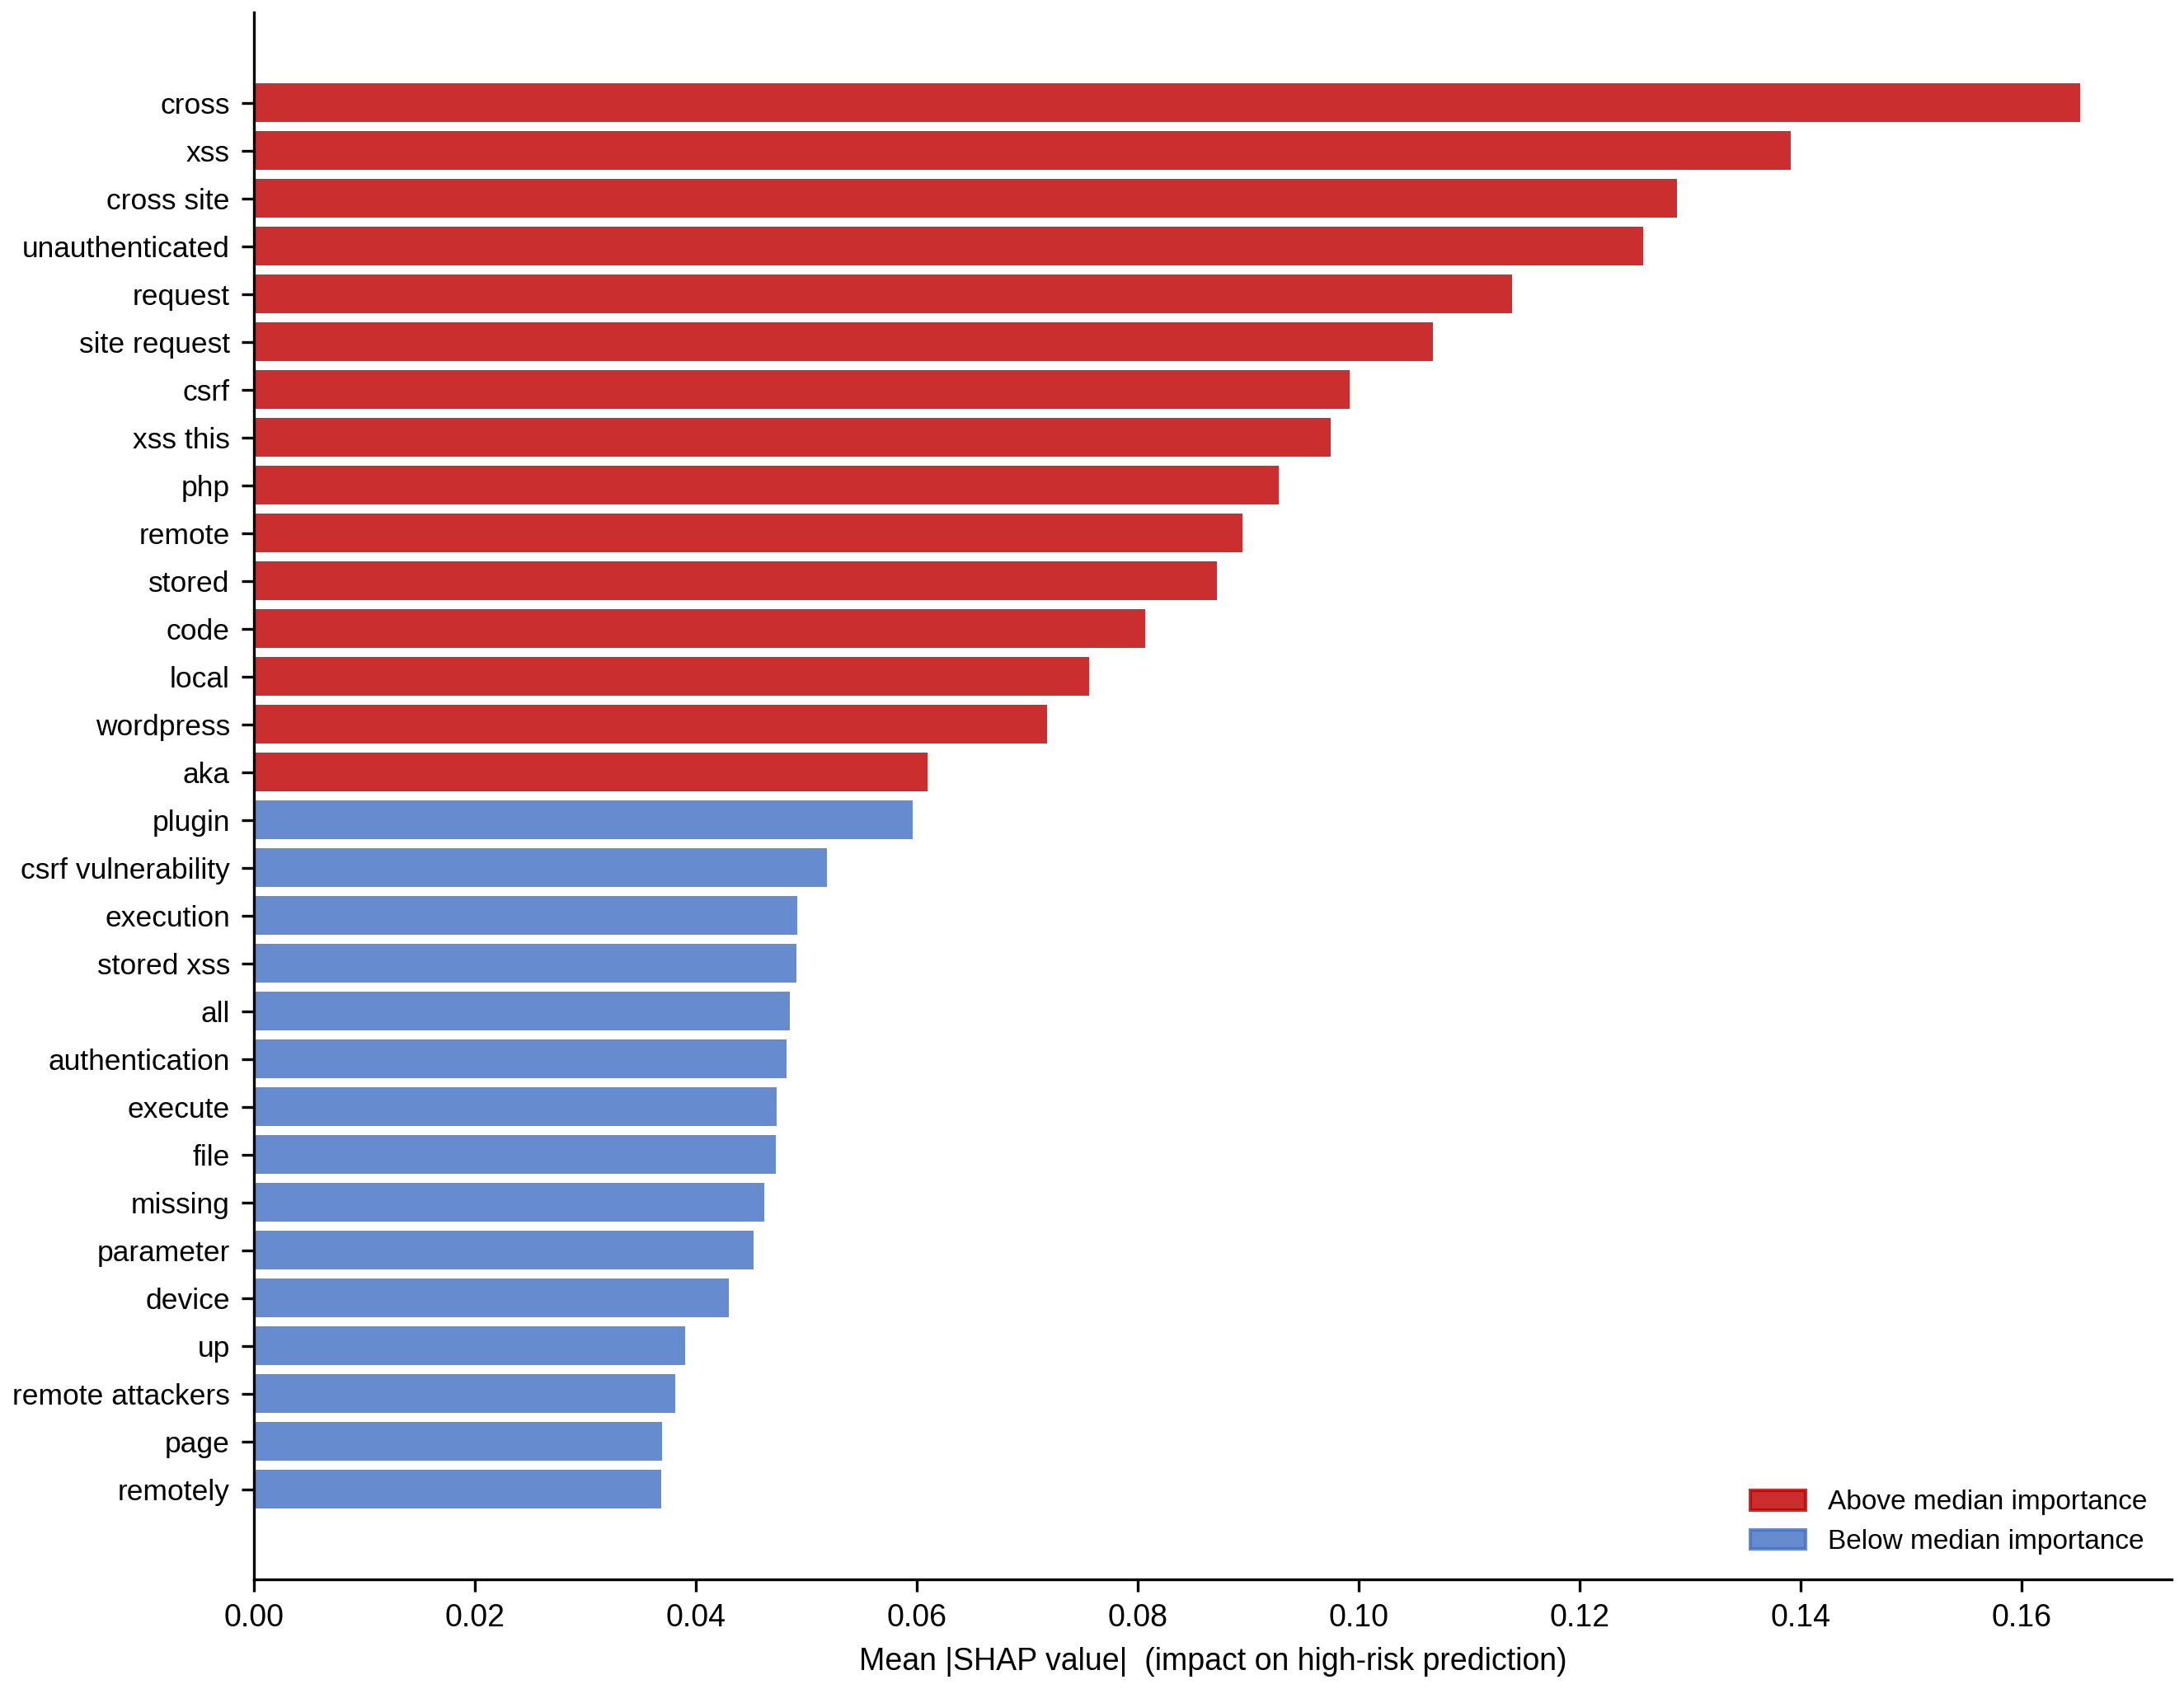

Figure 10 (clean) saved.

COMPARISON: Original vs Clean SHAP Top-30

Original Top-10:
   1. request
   2. the
   3. cross
   4. xss this
   5. cross site
   6. site request
   7. unauthenticated
   8. xss
   9. issue affects
  10. wordpress

Clean Top-10:
   1. cross                               0.16535
   2. xss                                 0.13911
   3. cross site                          0.12883
   4. unauthenticated                     0.12580
   5. request                             0.11390
   6. site request                        0.10672
   7. csrf                                0.09917
   8. xss this                            0.09745
   9. php                                 0.09278
  10. remote                              0.08947

Metrics comparison:
  Original: AUC=0.8820  PR-AUC=0.1234
  Clean:    AUC=0.8723  PR-AUC=0.1001
  Delta AUC: -0.0097

All done. Proceed to Step 2 (precision@k).


In [20]:

# ── CELL 7: Figure 10 updated — clean SHAP beeswarm ──────────
top30_names = np.array([f for f, _ in top_features])
top30_vals  = np.array([v for _, v in top_features])

fig, ax = plt.subplots(figsize=(9, 7))
colors = [C_RED if v > np.median(top30_vals) else C_BLUE
          for v in top30_vals]

ax.barh(range(len(top30_names)), top30_vals[::-1],
        color=colors[::-1], alpha=0.82, edgecolor="none")
ax.set_yticks(range(len(top30_names)))
ax.set_yticklabels(top30_names[::-1], fontsize=8.5)
ax.set_xlabel("Mean |SHAP value|  (impact on high-risk prediction)")
ax.axvline(0, color=C_GREY, lw=0.6)

patch_h = mpatches.Patch(color=C_RED, alpha=0.82,
                          label="Above median importance")
patch_l = mpatches.Patch(color=C_BLUE, alpha=0.82,
                          label="Below median importance")
ax.legend(handles=[patch_h, patch_l], loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "fig10_shap_m1_clean.pdf")
plt.savefig(DATA_DIR / "fig10_shap_m1_clean.png", dpi=300)
plt.show()
print("Figure 10 (clean) saved.")

# ── CELL 8: Comparison — original vs clean ────────────────────
print("\n" + "="*60)
print("COMPARISON: Original vs Clean SHAP Top-30")
print("="*60)

orig_names = np.load(DATA_DIR / "m1_shap_top30_names.npy",
                     allow_pickle=True)
print(f"\nOriginal Top-10:")
for i, n in enumerate(orig_names[:10], 1):
    marker = " ← ARTIFACT (function word)" if n in CVE_BIGRAM_STOPLIST else ""
    print(f"  {i:2d}. {n}{marker}")

print(f"\nClean Top-10:")
for i, (n, v) in enumerate(top_features[:10], 1):
    print(f"  {i:2d}. {n:<35s} {v:.5f}")

print(f"\nMetrics comparison:")
orig_auc = 0.8820; orig_prauc = 0.1234
print(f"  Original: AUC={orig_auc:.4f}  PR-AUC={orig_prauc:.4f}")
print(f"  Clean:    AUC={auc_clean:.4f}  PR-AUC={prauc_clean:.4f}")
delta_auc = auc_clean - orig_auc
print(f"  Delta AUC: {delta_auc:+.4f}")
print("\nAll done. Proceed to Step 2 (precision@k).")
